In [ ]:
import os, sys
import random
import pickle

import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
metrics_dir = '../runs'


In [ ]:
with open(os.path.join(metrics_dir, "IQN", "paper", "pre_flag_results.pkl"), "rb") as f:
    iqn_cql_results = pickle.load(f)

with open(os.path.join(metrics_dir, "IQNBaseline", "paper", "pre_flag_results.pkl"), "rb") as f:
    iqn_baseline_results = pickle.load(f)

with open(os.path.join(metrics_dir, "iqn_continuous_mimic", "pre_flag_results.pkl"), "rb") as f:
    cont_iqn_results = pickle.load(f)

In [ ]:
num_survivors = len(iqn_cql_results['survivors']['dn_q_selected_action_traj'])
num_nonsurvivors = len(iqn_cql_results['nonsurvivors']['dn_q_selected_action_traj'])
num_survivors_cont = len(cont_iqn_results['survivors']['dn_q_selected_action_traj'])
num_nonsurvivors_cont = len(cont_iqn_results['nonsurvivors']['dn_q_selected_action_traj'])

In [7]:
iqn_cql_results['nonsurvivors'].keys()

dict_keys(['dn_q_selected_action_traj', 'rn_q_selected_action_traj', 'stay_ids', 'dn_v_median_traj', 'rn_v_median_traj'])

In [11]:
iqn_cql_results['nonsurvivors']['dn_q_selected_action_traj'][0].shape

(49, 50)

In [13]:
iqn_cql_results['nonsurvivors']['dn_v_median_traj'][0].shape

(49, 50)

In [14]:
def create_analysis_df(results, num_survivors, num_nonsurvivors):
    """
    Create an indexable dataframe from the results data processed in `eval_rl.py`.
    
    Args:
        results (dict): a nested dictionary keyed by [nonsurvivors, survivors]x[traj] that contains the computed value of sequential state x treatment pairs
        num_survivors (int): the number of surviving patient trajectories
        num_nonsurvivors (int): the number of non_surviving patient trajectories

    Returns:
        surv_df (pd.DataFrame): A dataframe indexing the trajectory and step number for surviving patient trajectories
        nonsurv_df (pd.DataFrame): A dataframe indexing the trajectory and step number for nonsurviving patient trajectories
    """
    # Initialize the dictionaries that will be transformed into dataframes 
    surv_data = {'traj': [], 'step': [], 'q_dn': [], 'q_rn': [], 'v_dn': [], 'v_rn': [], 'stay_id': []}
    nonsurv_data = {'traj': [], 'step': [], 'q_dn': [], 'q_rn': [], 'v_dn': [], 'v_rn': [], 'stay_id': []}

    # Populate the dictionaries
    # First, the surviving patients
    surv_results = results['survivors']
    for traj in range(num_survivors):
        traj_qd = surv_results['dn_q_selected_action_traj'][traj]
        traj_qr = surv_results['rn_q_selected_action_traj'][traj]
        traj_vd = surv_results['dn_v_median_traj'][traj]
        traj_vr = surv_results['rn_v_median_traj'][traj]
        traj_sid = surv_results['stay_ids'][traj]

        for i in range(len(traj_qd)):
            surv_data['traj'].append(traj)
            surv_data['step'].append(i-len(traj_qd))
            surv_data['q_dn'].append(traj_qd[i])
            surv_data['q_rn'].append(traj_qr[i])
            surv_data['v_dn'].append(traj_vd[i])
            surv_data['v_rn'].append(traj_vr[i])
            surv_data['stay_id'].append(traj_sid)

    # Next, for the nonsurviving patients
    nonsurv_results = results['nonsurvivors']
    for traj in range(num_nonsurvivors):
        traj_qd = nonsurv_results['dn_q_selected_action_traj'][traj]
        traj_qr = nonsurv_results['rn_q_selected_action_traj'][traj]
        traj_vd = nonsurv_results['dn_v_median_traj'][traj]
        traj_vr = nonsurv_results['rn_v_median_traj'][traj]
        traj_sid = nonsurv_results['stay_ids'][traj]

        for i in range(len(traj_qd)):
            nonsurv_data['traj'].append(traj)
            nonsurv_data['step'].append(i-len(traj_qd))
            nonsurv_data['q_dn'].append(traj_qd[i])
            nonsurv_data['q_rn'].append(traj_qr[i])
            nonsurv_data['v_dn'].append(traj_vd[i])
            nonsurv_data['v_rn'].append(traj_vr[i])
            nonsurv_data['stay_id'].append(traj_sid)

    # Create the DataFrames from the populated dictionaries
    surv_df = pd.DataFrame(surv_data)
    nonsurv_df = pd.DataFrame(nonsurv_data)

    return surv_df, nonsurv_df

In [ ]:
iqn_cql_surv_df, iqn_cql_nonsurv_df = create_analysis_df(iqn_cql_results, num_survivors, num_nonsurvivors)
iqn_baseline_surv_df, iqn_baseline_nonsurv_df = create_analysis_df(iqn_baseline_results, num_survivors, num_nonsurvivors)
cont_surv_df, cont_nonsurv_df = create_analysis_df(cont_iqn_results, num_survivors_cont, num_nonsurvivors_cont)

In [ ]:
# Sanity check: f_D and f_R distributions for the continuous model (α = 0.05, col 0)
# f_D = -v_dn = fraction of dead-end actions from D-network
# f_R =  1 - v_rn = fraction of non-recovery actions from R-network
# Both should be higher for non-survivors if the model has learned something useful.

def _traj_scores(df, col, alpha_col=0, agg='mean'):
    out = []
    for t in sorted(df.traj.unique()):
        vals = _stack_traj_values(df[df.traj == t][col])[:, alpha_col]
        out.append(vals.mean() if agg == 'mean' else vals.max())
    return np.array(out, dtype=np.float32)

ns_fD = -_traj_scores(cont_nonsurv_df, 'v_dn')
ns_fR =  1 - _traj_scores(cont_nonsurv_df, 'v_rn')
s_fD  = -_traj_scores(cont_surv_df,    'v_dn')
s_fR  =  1 - _traj_scores(cont_surv_df,    'v_rn')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Continuous IQN — Sanity Check (α = 0.05)")
for ax, ns, s, title, xlabel in [
    (axes[0], ns_fD, s_fD, "D-network dead-end fraction",     "mean f_D over trajectory"),
    (axes[1], ns_fR, s_fR, "R-network non-recovery fraction", "mean f_R over trajectory"),
]:
    ax.hist(s,  bins=30, alpha=0.6, color='green',    label=f'Survivors (μ={s.mean():.3f})')
    ax.hist(ns, bins=30, alpha=0.6, color='steelblue', label=f'Non-survivors (μ={ns.mean():.3f})')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=9)
sns.despine(fig)
plt.tight_layout()
plt.show()

print(f"f_D — non-survivors: {ns_fD.mean():.4f} ± {ns_fD.std():.4f}  |  survivors: {s_fD.mean():.4f} ± {s_fD.std():.4f}")
print(f"f_R — non-survivors: {ns_fR.mean():.4f} ± {ns_fR.std():.4f}  |  survivors: {s_fR.mean():.4f} ± {s_fR.std():.4f}")

In [13]:
def plot_values(axs, nonsurv_data, surv_data, step_num, var_idx=None, nb_bar=10):
    """Plot histograms of the computed values for Q_D, Q_R (for selected actions) and V_D, V_R (median over all actions)."""
    if var_idx is not None:  # If we've supplied the VaR index we have an array of values per timestep, we need to account for this differently...
        hr_death, bins_r_death = np.histogram(np.vstack(nonsurv_data[(nonsurv_data.step==step_num)]['q_rn'].values)[:, var_idx], np.linspace(0, 1, num=nb_bar+1, endpoint=True), density=False)
        hd_death, bins_d_death = np.histogram(np.vstack(nonsurv_data[(nonsurv_data.step==step_num)]['q_dn'].values)[:, var_idx], np.linspace(-1, 0, num=nb_bar+1, endpoint=True), density=False)
        hr_recovery, bins_r_recovery = np.histogram(np.vstack(surv_data[(surv_data.step ==step_num)]['q_rn'].values)[:, var_idx], np.linspace(0, 1, num=nb_bar+1, endpoint=True), density=False)
        hd_recovery, bins_d_recovery = np.histogram(np.vstack(surv_data[(surv_data.step ==step_num)]['q_dn'].values)[:, var_idx], np.linspace(-1, 0, num=nb_bar+1, endpoint=True), density=False)
        hvr_death, bins_vr_death = np.histogram(np.vstack(nonsurv_data[(nonsurv_data.step==step_num)]['v_rn'].values)[:, var_idx], np.linspace(0, 1, num=nb_bar+1, endpoint=True), density=False)
        hvd_death, bins_vd_death = np.histogram(np.vstack(nonsurv_data[(nonsurv_data.step==step_num)]['v_dn'].values)[:, var_idx], np.linspace(-1, 0, num=nb_bar+1, endpoint=True), density=False)
        hvr_recovery, bins_vr_recovery = np.histogram(np.vstack(surv_data[(surv_data.step==step_num)]['v_rn'].values)[:, var_idx], np.linspace(0, 1, num=nb_bar+1, endpoint=True), density=False)
        hvd_recovery, bins_vd_recovery = np.histogram(np.vstack(surv_data[(surv_data.step==step_num)]['v_dn'].values)[:, var_idx], np.linspace(-1, 0, num=nb_bar+1, endpoint=True), density=False)
    else:
        hr_death, bins_r_death = np.histogram(nonsurv_data[(nonsurv_data.step==step_num)]['q_rn'].values, np.linspace(0, 1, num=nb_bar+1, endpoint=True), density=False)
        hd_death, bins_d_death = np.histogram(nonsurv_data[(nonsurv_data.step==step_num)]['q_dn'].values, np.linspace(-1, 0, num=nb_bar+1, endpoint=True), density=False)
        hr_recovery, bins_r_recovery = np.histogram(surv_data[(surv_data.step ==step_num)]['q_rn'].values, np.linspace(0, 1, num=nb_bar+1, endpoint=True), density=False)
        hd_recovery, bins_d_recovery = np.histogram(surv_data[(surv_data.step ==step_num)]['q_dn'].values, np.linspace(-1, 0, num=nb_bar+1, endpoint=True), density=False)
        hvr_death, bins_vr_death = np.histogram(nonsurv_data[(nonsurv_data.step==step_num)]['v_rn'].values, np.linspace(0, 1, num=nb_bar+1, endpoint=True), density=False)
        hvd_death, bins_vd_death = np.histogram(nonsurv_data[(nonsurv_data.step==step_num)]['v_dn'].values, np.linspace(-1, 0, num=nb_bar+1, endpoint=True), density=False)
        hvr_recovery, bins_vr_recovery = np.histogram(surv_data[(surv_data.step==step_num)]['v_rn'].values, np.linspace(0, 1, num=nb_bar+1, endpoint=True), density=False)
        hvd_recovery, bins_vd_recovery = np.histogram(surv_data[(surv_data.step==step_num)]['v_dn'].values, np.linspace(-1, 0, num=nb_bar+1, endpoint=True), density=False)

    hr_death_total = np.sum(hr_death)
    hd_death_total = np.sum(hd_death)
    hr_recovery_total = np.sum(hr_recovery)
    hd_recovery_total = np.sum(hd_recovery)
    hvr_death_total = np.sum(hvr_death)
    hvd_death_total = np.sum(hvd_death)
    hvr_recovery_total = np.sum(hvr_recovery)
    hvd_recovery_total = np.sum(hvd_recovery)

    bar_width = 1. / (nb_bar)
    w = (bar_width - (bar_width / 6)) / 2  # so that two bars fits nicely

    x = np.linspace(0, 1, num=nb_bar+1, endpoint=True)[:-1] + bar_width/2
    y = np.linspace(-1, 0, num=nb_bar+1, endpoint=True)[:-1] + bar_width/2
    rects1 = axs[0].bar(y - w/2, hd_death/hd_death_total, w, label='Non-survivors', color='blue', alpha=1) 
    rects2 = axs[0].bar(y + w/2, hd_recovery/hd_recovery_total, w, label='Survivors', color='green', alpha=1)
    rects3 = axs[1].bar(x - w/2, hr_death/hr_death_total, w, label='Non-survivors', color='blue', alpha=1)
    rects4 = axs[1].bar(x + w/2, hr_recovery/hr_recovery_total, w, label='Survivors', color='green', alpha=1)
    rects5 = axs[2].bar(y - w/2, hvd_death/hvd_death_total, w, label='Non-survivors', color='blue', alpha=1) 
    rects6 = axs[2].bar(y + w/2, hvd_recovery/hvd_recovery_total, w, label='Survivors', color='green', alpha=1)
    rects7 = axs[3].bar(x - w/2, hvr_death/hvr_death_total, w, label='Non-survivors', color='blue', alpha=1)
    rects8 = axs[3].bar(x + w/2, hvr_recovery/hvr_recovery_total, w, label='Survivors', color='green', alpha=1)


    xx = np.linspace(0, 1, num=nb_bar+1, endpoint=True)
    yy = np.linspace(-1, 0, num=nb_bar+1, endpoint=True)

    axs[0].set_ylim(0, 1)
    axs[0].set_xticks(list(y))

    axs[0].set_xticklabels("" * len(yy - 1))

    axs[0].set_yticks([0, 0.5, 1])
    axs[0].set_yticklabels(['0%', '50%', '100%'])

    axs[1].set_ylim(0, 1)
    axs[1].set_xticks(list(x))

    axs[1].set_xticklabels("" * len(xx - 1))

    axs[1].set_yticks([0, 0.5, 1])
    axs[1].set_yticklabels(['0%', '50%', '100%'])


    axs[2].set_ylim(0, 1)
    axs[2].set_xticks(list(y))
    
    axs[2].set_xticklabels("" * len(xx - 1))

    axs[2].set_yticks([0, 0.5, 1])
    axs[2].set_yticklabels(['0%', '50%', '100%'])

    axs[3].set_ylim(0, 1)
    axs[3].set_xticks(list(x))
    
    axs[3].set_xticklabels(["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"])

    axs[3].set_yticks([0, 0.5, 1])
    axs[3].set_yticklabels(['0%', '50%', '100%'])

    
    axs[0].set_title('D-Network (Q)', fontsize=7)
    axs[1].set_title('R-Network (Q)', fontsize=7)
    axs[2].set_title('D-Network (V)', fontsize=7)
    axs[3].set_title('R-Network (V)', fontsize=7)


In [ ]:
hist_steps = [-72, -48, -24, -12, -8, -4, -1]
VaR_thresholds = np.round(np.linspace(0.05, 1.0, num=20), decimals=2)

for model_name, surv_df, nonsurv_df in [
        ("IQN+CQL", iqn_cql_surv_df, iqn_cql_nonsurv_df),
        ("IQN Baseline", iqn_baseline_surv_df, iqn_baseline_nonsurv_df),
]:
    for ivar, _ in enumerate(VaR_thresholds):
        fig, full_axs = plt.subplots(4, len(hist_steps), figsize=(24, 6), dpi=500, sharey=True)
        fig.suptitle(f"{model_name} — CVaR threshold {VaR_thresholds[ivar]:.2f}")
        for i, step_num in enumerate(hist_steps):
            axs = full_axs[:, i]
            plot_values(axs, nonsurv_df, surv_df, step_num, var_idx=ivar)
        fig.tight_layout()
        sns.despine(fig)
        fig.show()
        plt.close(fig)

In [28]:
class th:
    ded_dn_red = -0.25
    ded_rn_red = 0.75

    ded_dn_yel = -0.15
    ded_rn_yel = 0.85

    ded_dn_gry1 = -0.10
    ded_rn_gry1 = 0.90
    
    ded_dn_gry2 = -0.05
    ded_rn_gry2 = 0.95

    new_dn_red = -0.6
    new_rn_red = 0.4

    new_dn_yel = -0.5
    new_rn_yel = 0.5

In [29]:
window_pre = 12
window_post = 8

In [ ]:
thresh_array = np.linspace(0, 1.0, 1001, dtype=np.float32)
use_gpu = torch.cuda.is_available()
device = torch.device("cuda" if use_gpu else "cpu")
print(f"Acceleration device: {device}")

In [31]:
thresh_array

array([0.   , 0.001, 0.002, ..., 0.998, 0.999, 1.   ])

In [ ]:
def compare_flag_range(row):
    vd = np.asarray(row["v_dn"], dtype=np.float32)
    vr = np.asarray(row["v_rn"], dtype=np.float32)
    if vd.ndim == 0:
        return np.logical_and(vd < (thresh_array - 1.0), vr < thresh_array)
    return np.logical_and(vd[None, :] < (thresh_array[:, None] - 1.0),
                          vr[None, :] < thresh_array[:, None])

def _stack_traj_values(series):
    first_val = series.iloc[0]
    if np.isscalar(first_val):
        return series.to_numpy(dtype=np.float32)[:, None]
    return np.vstack(list(series.values)).astype(np.float32)

def compute_flag_tensor(v_dn, v_rn, thresholds, use_gpu=False, device=None):
    """Return flags with shape (num_steps, num_thresholds, num_var)."""
    thresholds = thresholds.astype(np.float32, copy=False)
    if use_gpu and torch.cuda.is_available():
        active_device = device if device is not None else torch.device("cuda")
        vd = torch.as_tensor(v_dn, dtype=torch.float32, device=active_device)
        vr = torch.as_tensor(v_rn, dtype=torch.float32, device=active_device)
        thr = torch.as_tensor(thresholds, dtype=torch.float32, device=active_device)
        flags = (vd[:, None, :] < (thr[None, :, None] - 1.0)) & (vr[:, None, :] < thr[None, :, None])
        return flags.cpu().numpy()
    return (v_dn[:, None, :] < (thresholds[None, :, None] - 1.0)) & (v_rn[:, None, :] < thresholds[None, :, None])

def compute_traj_flags(traj_df, thresholds, use_gpu=False, device=None):
    v_dn = _stack_traj_values(traj_df['v_dn'])
    v_rn = _stack_traj_values(traj_df['v_rn'])
    return compute_flag_tensor(v_dn, v_rn, thresholds, use_gpu=use_gpu, device=device)

def first_flag_hours(v_dn, v_rn, steps, dn_threshold, rn_threshold):
    """For each VaR column, return hours ahead of first threshold crossing, else NaN."""
    flagged = (v_dn < dn_threshold) & (v_rn < rn_threshold)
    has_flag = np.any(flagged, axis=0)
    first_idx = np.argmax(flagged, axis=0)
    out = np.full(v_dn.shape[1], np.nan, dtype=np.float32)
    out[has_flag] = -steps[first_idx[has_flag]]
    return out

In [33]:
def compare_ded_red(row):
    return np.logical_and(row['v_dn']<th.ded_dn_red, row["v_rn"]<th.ded_rn_red)

def compare_ded_yellow(row):
    return np.logical_and(row['v_dn']<th.ded_dn_yel, row["v_rn"]<th.ded_rn_yel)

def compare_red(row):
    return np.logical_and(row['v_dn']<th.new_dn_red, row['v_rn']<th.new_rn_red)
    
def compare_yellow(row):
    return np.logical_and(row['v_dn']<th.new_dn_yel, row['v_rn']<th.new_rn_yel)

In [34]:
iqn_cql_nonsurv_df.head()

,traj,step,q_dn,q_rn,v_dn,v_rn,stay_id,presumed_onset
0,0,-49,"[nan, -0.09415103495121002, -0.080473020672798...","[nan, 0.8159421682357788, 0.8405247926712036, ...","[nan, -0.11539353430271149, -0.102969601750373...","[nan, 0.7800806760787964, 0.7980253100395203, ...",33922519.0,"(-49, Sepsis)"
1,0,-48,"[nan, -0.055356670171022415, -0.04299173131585...","[nan, 0.7686188817024231, 0.7934525012969971, ...","[nan, -0.08175963908433914, -0.066515170037746...","[nan, 0.832309901714325, 0.8596318960189819, 0...",33922519.0,"(-49, Sepsis)"
2,0,-47,"[nan, -0.06453734636306763, -0.051234252750873...","[nan, 0.7686487436294556, 0.790939211845398, 0...","[nan, -0.06453734636306763, -0.058309417217969...","[nan, 0.8144391179084778, 0.8371427655220032, ...",33922519.0,"(-49, Sepsis)"
3,0,-46,"[nan, -0.06189756467938423, -0.056010521948337...","[nan, 0.7306861281394958, 0.7680474519729614, ...","[nan, -0.07079274952411652, -0.064160749316215...","[nan, 0.7848454713821411, 0.8139649629592896, ...",33922519.0,"(-49, Sepsis)"
4,0,-45,"[nan, -0.0557299479842186, -0.0440974310040473...","[nan, 0.7772651314735413, 0.8138009309768677, ...","[nan, -0.0828574001789093, -0.0725805908441543...","[nan, 0.7534087300300598, 0.790300726890564, 0...",33922519.0,"(-49, Sepsis)"


In [35]:
iqn_cql_nonsurv_df[iqn_cql_nonsurv_df.traj==0]

,traj,step,q_dn,q_rn,v_dn,v_rn,stay_id,presumed_onset
0,0,-49,"[nan, -0.09415103495121002, -0.080473020672798...","[nan, 0.8159421682357788, 0.8405247926712036, ...","[nan, -0.11539353430271149, -0.102969601750373...","[nan, 0.7800806760787964, 0.7980253100395203, ...",33922519.0,"(-49, Sepsis)"
1,0,-48,"[nan, -0.055356670171022415, -0.04299173131585...","[nan, 0.7686188817024231, 0.7934525012969971, ...","[nan, -0.08175963908433914, -0.066515170037746...","[nan, 0.832309901714325, 0.8596318960189819, 0...",33922519.0,"(-49, Sepsis)"
2,0,-47,"[nan, -0.06453734636306763, -0.051234252750873...","[nan, 0.7686487436294556, 0.790939211845398, 0...","[nan, -0.06453734636306763, -0.058309417217969...","[nan, 0.8144391179084778, 0.8371427655220032, ...",33922519.0,"(-49, Sepsis)"
3,0,-46,"[nan, -0.06189756467938423, -0.056010521948337...","[nan, 0.7306861281394958, 0.7680474519729614, ...","[nan, -0.07079274952411652, -0.064160749316215...","[nan, 0.7848454713821411, 0.8139649629592896, ...",33922519.0,"(-49, Sepsis)"
4,0,-45,"[nan, -0.0557299479842186, -0.0440974310040473...","[nan, 0.7772651314735413, 0.8138009309768677, ...","[nan, -0.0828574001789093, -0.0725805908441543...","[nan, 0.7534087300300598, 0.790300726890564, 0...",33922519.0,"(-49, Sepsis)"
5,0,-44,"[nan, -0.024628162384033203, -0.01702120527625...","[nan, 0.7739771604537964, 0.8070672750473022, ...","[nan, -0.066181980073452, -0.06204108521342277...","[nan, 0.8470839262008667, 0.8727771043777466, ...",33922519.0,"(-49, Sepsis)"
6,0,-43,"[nan, -0.07279354333877563, -0.065168388187885...","[nan, 0.7308896780014038, 0.7721783518791199, ...","[nan, -0.05840955302119255, -0.049402579665184...","[nan, 0.7796459794044495, 0.8115822076797485, ...",33922519.0,"(-49, Sepsis)"
7,0,-42,"[nan, -0.07482825219631195, -0.057542789727449...","[nan, 0.7827709317207336, 0.8083890080451965, ...","[nan, -0.08415824919939041, -0.075341925024986...","[nan, 0.7260688543319702, 0.7605056166648865, ...",33922519.0,"(-49, Sepsis)"
8,0,-41,"[nan, -0.12590381503105164, -0.111159607768058...","[nan, 0.7121358513832092, 0.7651419043540955, ...","[nan, -0.0920703262090683, -0.0769523605704307...","[nan, 0.7905552983283997, 0.8237664103507996, ...",33922519.0,"(-49, Sepsis)"
9,0,-40,"[nan, -0.07701332867145538, -0.061529945582151...","[nan, 0.806591808795929, 0.838601291179657, 0....","[nan, -0.08930046111345291, -0.076642557978630...","[nan, 0.7510377168655396, 0.79274582862854, 0....",33922519.0,"(-49, Sepsis)"


In [ ]:
iqn_ns_dt = iqn_cql_nonsurv_df[iqn_cql_nonsurv_df.traj == 0]
iqn_vdn = _stack_traj_values(iqn_ns_dt['v_dn'])
iqn_vrn = _stack_traj_values(iqn_ns_dt['v_rn'])
iqn_ns_yellow_flags = np.logical_and(iqn_vdn < th.new_dn_yel, iqn_vrn < th.new_rn_yel)
iqn_ns_red_flags = np.logical_and(iqn_vdn < th.new_dn_red, iqn_vrn < th.new_rn_red)
iqn_comp_flags = compute_traj_flags(iqn_ns_dt, thresh_array, use_gpu=use_gpu, device=device)

In [44]:
iqn_comp_flags.shape

(49, 1001, 50)

In [47]:
np.any(iqn_comp_flags[...,0], axis=0)

array([False, False, False, ..., False, False, False])

In [50]:
temp_yellow = iqn_ns_yellow_flags * np.expand_dims(np.arange(len(iqn_ns_yellow_flags)), -1)
temp_yellow[~iqn_ns_yellow_flags] = -1

In [51]:
temp_red = iqn_ns_red_flags * np.expand_dims(np.arange(len(iqn_ns_red_flags)), -1)
temp_red[~iqn_ns_red_flags] = -1

In [52]:
var_thresholds = np.round(np.linspace(0.05, 1.0, num=20), decimals=2)

In [ ]:
iqn_colors = sns.color_palette("Greens", n_colors=20)

for model_name, ns_dt, ns_yellow_flags, ns_red_flags, colors in [
        ("IQN+CQL",     iqn_ns_dt, iqn_ns_yellow_flags, iqn_ns_red_flags, iqn_colors),
]:
    temp_yellow_m = ns_yellow_flags * np.expand_dims(np.arange(len(ns_yellow_flags)), -1)
    temp_yellow_m[~ns_yellow_flags] = -1
    temp_red_m = ns_red_flags * np.expand_dims(np.arange(len(ns_red_flags)), -1)
    temp_red_m[~ns_red_flags] = -1

    fig, axs = plt.subplots(2, 2, figsize=(20, 16), dpi=300, sharex=True)
    fig.suptitle(model_name)
    for i, item in enumerate(['q_dn', 'q_rn', 'v_dn', 'v_rn']):
        ax = axs[i//2, i%2]
        ns_item  = np.vstack(ns_dt[item].values)
        ns_steps = ns_dt.step.values
        for ivar in range(20):
            sns.lineplot(x=ns_steps, y=ns_item[:, ivar], color=colors[ivar], linewidth=1, ax=ax)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        ax.set_ylabel("")
        ax.scatter(temp_yellow_m - len(ns_steps),
                   np.repeat(np.expand_dims(var_thresholds, 0), len(ns_yellow_flags), axis=0),
                   color='xkcd:goldenrod')
        ax.scatter(temp_red_m - len(ns_steps),
                   np.repeat(np.expand_dims(var_thresholds, 0), len(ns_red_flags), axis=0),
                   color='xkcd:tomato')
        ax.set_xlim([-len(ns_steps), 0])
    plt.show()

In [ ]:
nonsurv_data_iqn_cql      = np.zeros((num_nonsurvivors, 1001, 20), dtype=np.float32)
surv_data_iqn_cql         = np.zeros((num_survivors,    1001, 20), dtype=np.float32)
nonsurv_data_iqn_baseline = np.zeros((num_nonsurvivors, 1001, 20), dtype=np.float32)
surv_data_iqn_baseline    = np.zeros((num_survivors,    1001, 20), dtype=np.float32)

nonsurv_data_cont = np.zeros((num_nonsurvivors_cont, 1001, 20), dtype=np.float32)
surv_data_cont    = np.zeros((num_survivors_cont,    1001, 20), dtype=np.float32)

for traj in range(num_nonsurvivors):
    for arr, df in [(nonsurv_data_iqn_cql,      iqn_cql_nonsurv_df),
                    (nonsurv_data_iqn_baseline, iqn_baseline_nonsurv_df)]:
        dt = df[df.traj == traj]
        flags = compute_traj_flags(dt, thresh_array, use_gpu=use_gpu, device=device)
        arr[traj, :, :] = np.any(flags, axis=0).astype(np.float32)

for traj in range(num_survivors):
    for arr, df in [(surv_data_iqn_cql,      iqn_cql_surv_df),
                    (surv_data_iqn_baseline, iqn_baseline_surv_df)]:
        dt = df[df.traj == traj]
        flags = compute_traj_flags(dt, thresh_array, use_gpu=use_gpu, device=device)
        arr[traj, :, :] = np.any(flags, axis=0).astype(np.float32)

for traj in range(num_nonsurvivors_cont):
    dt = cont_nonsurv_df[cont_nonsurv_df.traj == traj]
    flags = compute_traj_flags(dt, thresh_array, use_gpu=use_gpu, device=device)
    nonsurv_data_cont[traj, :, :] = np.any(flags, axis=0).astype(np.float32)

for traj in range(num_survivors_cont):
    dt = cont_surv_df[cont_surv_df.traj == traj]
    flags = compute_traj_flags(dt, thresh_array, use_gpu=use_gpu, device=device)
    surv_data_cont[traj, :, :] = np.any(flags, axis=0).astype(np.float32)

In [ ]:
print("IQN+CQL:", surv_data_iqn_cql.shape, nonsurv_data_iqn_cql.shape)
print("IQN Baseline:", surv_data_iqn_baseline.shape, nonsurv_data_iqn_baseline.shape)
print("Continuous IQN:", surv_data_cont.shape, nonsurv_data_cont.shape)

In [ ]:
fpr_iqn_cql      = np.sum(surv_data_iqn_cql,      axis=0) / num_survivors
tpr_iqn_cql      = np.sum(nonsurv_data_iqn_cql,   axis=0) / num_nonsurvivors

fpr_iqn_baseline = np.sum(surv_data_iqn_baseline, axis=0) / num_survivors
tpr_iqn_baseline = np.sum(nonsurv_data_iqn_baseline, axis=0) / num_nonsurvivors

fpr_cont = np.sum(surv_data_cont, axis=0) / num_survivors_cont
tpr_cont = np.sum(nonsurv_data_cont, axis=0) / num_nonsurvivors_cont

In [ ]:
from sklearn.metrics import auc as sklearn_auc

def compute_sorted_auc(fpr, tpr, n=20):
    srt_fpr = np.zeros_like(fpr)
    srt_tpr = np.zeros_like(tpr)
    auc_arr = np.zeros(n)
    for ii in range(n):
        idx = np.argsort(fpr[:, ii])
        srt_fpr[:, ii] = fpr[idx, ii]
        srt_tpr[:, ii] = tpr[idx, ii]
        auc_arr[ii] = sklearn_auc(srt_fpr[:, ii], srt_tpr[:, ii])
    return srt_fpr, srt_tpr, auc_arr

srt_fpr_iqn_cql,      srt_tpr_iqn_cql,      iqn_cql_auc_arr      = compute_sorted_auc(fpr_iqn_cql,      tpr_iqn_cql)
srt_fpr_iqn_baseline, srt_tpr_iqn_baseline, iqn_baseline_auc_arr = compute_sorted_auc(fpr_iqn_baseline, tpr_iqn_baseline)
srt_fpr_cont,         srt_tpr_cont,         cont_auc_arr         = compute_sorted_auc(fpr_cont,         tpr_cont)

print("IQN+CQL      AUC per VaR:", np.round(iqn_cql_auc_arr, 4))
print("IQN Baseline AUC per VaR:", np.round(iqn_baseline_auc_arr, 4))
print("Continuous   AUC per VaR:", np.round(cont_auc_arr, 4))

In [19]:
plt.rcParams.update({'font.size': 22})

In [60]:
from sklearn.metrics import auc

In [ ]:
iqn_palette      = sns.color_palette("Greens",  n_colors=20)
iqn_base_palette = sns.color_palette("Oranges", n_colors=20)
cont_palette     = sns.color_palette("Purples", n_colors=20)

plt.figure(figsize=(10, 8))
for ii in range(20):
    plt.plot(srt_fpr_iqn_cql[:, ii], srt_tpr_iqn_cql[:, ii],
             color=iqn_palette[ii], lw=3, label="IQN+CQL" if ii == 19 else "", alpha=0.75)
for ii in range(20):
    plt.plot(srt_fpr_iqn_baseline[:, ii], srt_tpr_iqn_baseline[:, ii],
             color=iqn_base_palette[ii], lw=3, label="IQN Baseline" if ii == 19 else "", alpha=0.75)
for ii in range(20):
    plt.plot(srt_fpr_cont[:, ii], srt_tpr_cont[:, ii],
             color=cont_palette[ii], lw=3, label="Continuous IQN" if ii == 19 else "", alpha=0.75)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.grid()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=16)
plt.xlim([0., 1.])
plt.ylim([0., 1.])
plt.axis("square")
plt.title("ROC Curves per Quantile Level α")
plt.show()

In [64]:
mean_fpr = np.mean(srt_fpr_iqn_cql, axis=1)
mean_tpr = np.mean(srt_tpr_iqn_cql, axis=1)
std_fpr = np.std(srt_fpr_iqn_cql, axis=1)
std_tpr = np.std(srt_tpr_iqn_cql, axis=1)

In [ ]:
iqn_palette      = sns.color_palette("Greens",  n_colors=20)
iqn_base_palette = sns.color_palette("Oranges", n_colors=20)

plt.figure(figsize=(10, 8))
for ii in range(20):
    plt.plot(srt_fpr_iqn_cql[:, ii], srt_tpr_iqn_cql[:, ii],
             color=iqn_palette[ii], lw=3, label="IQN+CQL (DistDeD)" if ii == 19 else "", alpha=0.95)
for ii in range(20):
    plt.plot(srt_fpr_iqn_baseline[:, ii], srt_tpr_iqn_baseline[:, ii],
             color=iqn_base_palette[ii], lw=3, label="IQN Baseline" if ii == 19 else "", alpha=0.95)
plt.grid()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=16)
plt.xlim([0., 1.])
plt.ylim([0., 1.])
plt.axis("square")
plt.title("ROC Curves per Quantile Level α")
plt.show()

In [ ]:
VaR_thresholds_plot = np.round(np.linspace(0.05, 1.0, num=20), decimals=2)
plt.figure(figsize=(10, 8))
plt.plot(VaR_thresholds_plot, iqn_cql_auc_arr,      '*-', markersize=9.5, color='green',      lw=4, label='IQN+CQL (DistDeD)')
plt.plot(VaR_thresholds_plot, iqn_baseline_auc_arr,  's-', markersize=9.5, color='darkorange', lw=4, label='IQN Baseline')
plt.plot(VaR_thresholds_plot, cont_auc_arr,          'd-', markersize=9.5, color='purple',    lw=4, label='Continuous IQN')
plt.ylabel("AUC")
plt.xlabel("VaR Threshold")
plt.legend(fontsize=16)
plt.xlim([0, 1.05])
plt.grid()
plt.title("Dead-End Detection AUC vs Quantile Level α")
plt.show()

### Histograms for IQN+CQL

Now, let's compare between DistDeD and DeD

In [ ]:
ns_cql_flags = []
for traj in range(num_nonsurvivors):
    dt = iqn_cql_nonsurv_df[iqn_cql_nonsurv_df.traj == traj]
    v_dn = _stack_traj_values(dt['v_dn'])
    v_rn = _stack_traj_values(dt['v_rn'])
    steps = dt['step'].to_numpy()
    traj_flags = first_flag_hours(v_dn, v_rn, steps, th.ded_dn_red, th.ded_rn_red)
    ns_cql_flags.append(traj_flags)
diff_in_flags_Sepsis_ns_cql = np.vstack(ns_cql_flags)  # (num_nonsurvivors, 20)
temp_diffs_cql = diff_in_flags_Sepsis_ns_cql  # (num_nonsurvivors, 20) — all VaR thresholds

In [ ]:
temp = np.repeat(VaR_thresholds[None, :], temp_diffs_cql.shape[0], axis=0)

In [ ]:
composite_ns_flags_cql = np.hstack([temp_diffs_cql.flatten('F')[:, None], temp.flatten('F')[:, None]])
composite_ns_flags_cql.shape

In [ ]:
ns_flags_cql_df = pd.DataFrame(composite_ns_flags_cql, columns=['Hours Ahead', 'VaR Threshold'])

In [143]:
ns_flags_cql_df['type'] = 'Non-surviving Patients'

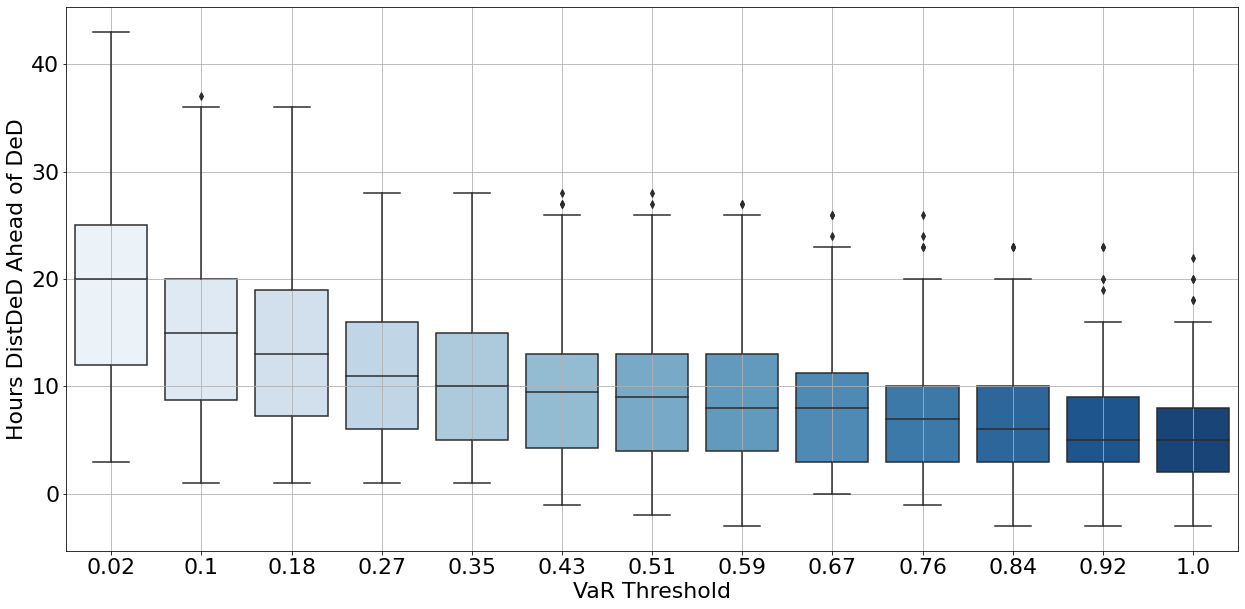

In [144]:
plt.figure(figsize=(30,10))
sns.boxplot(x='VaR Threshold', y='Hours Ahead', data=ns_flags_cql_df, palette="Blues")
plt.grid()
plt.title("IQN+CQL: Non-surviving, Hours Ahead")
plt.show()

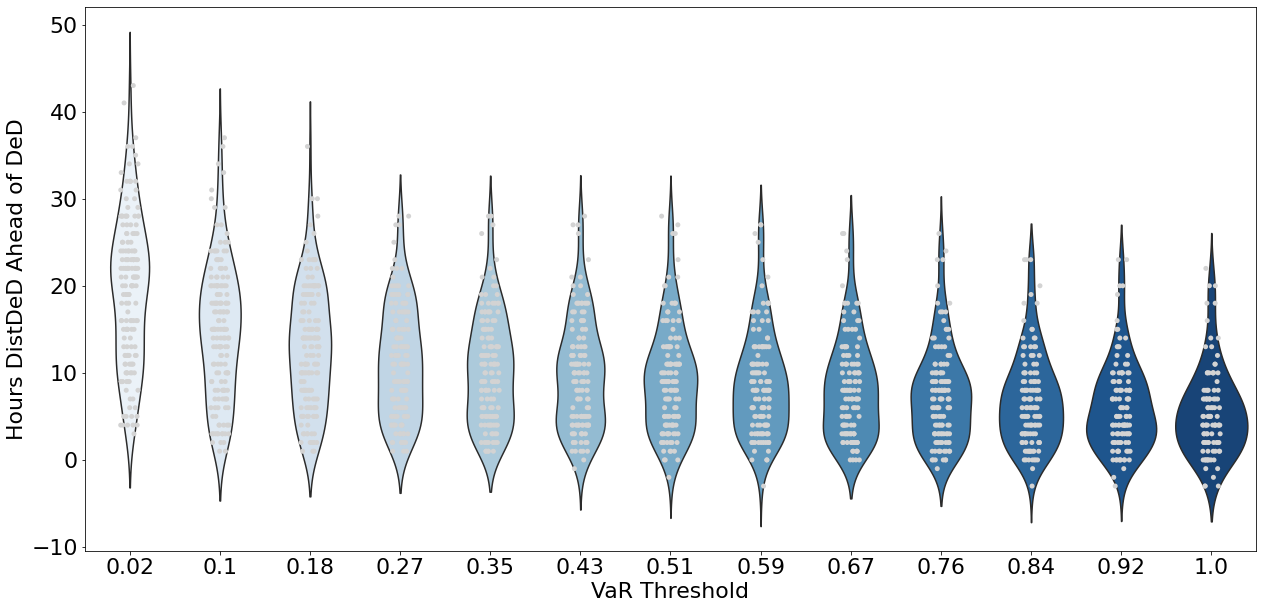

In [145]:
plt.figure(figsize=(21,10))
sns.violinplot(x="VaR Threshold", y="Hours Ahead", data=ns_flags_cql_df, palette="Blues", inner=None)
sns.stripplot(x="VaR Threshold", y="Hours Ahead", data=ns_flags_cql_df, color="lightgray", edgecolor="gray")
plt.title("IQN+CQL: Non-surviving, Hours Ahead")
plt.show()

### Analysis of flags for surviving patients

In [118]:
num_survivors

1359

In [119]:
1359-288

1071

In [ ]:
s_cql_flags = []
for traj in range(num_survivors):
    dt = iqn_cql_surv_df[iqn_cql_surv_df.traj == traj]
    v_dn = _stack_traj_values(dt['v_dn'])
    v_rn = _stack_traj_values(dt['v_rn'])
    steps = dt['step'].to_numpy()
    traj_flags = first_flag_hours(v_dn, v_rn, steps, th.ded_dn_red, th.ded_rn_red)
    s_cql_flags.append(traj_flags)
diff_in_flags_Sepsis_s_cql = np.vstack(s_cql_flags)  # (num_survivors, 20)

### IQN+CQL Histograms for Surviving patients

In [131]:
temp_diffs = diff_in_flags_Sepsis_s_cql  # all 20 VaR thresholds

In [132]:
temp = np.repeat(VaR_thresholds[None, :], temp_diffs.shape[0], axis=0)

In [133]:
composite_s_flags_cql = np.hstack([temp_diffs.flatten('F')[:, None], temp.flatten('F')[:, None]])
composite_s_flags_cql.shape

(13923, 2)

In [134]:
s_flags_cql_df = pd.DataFrame(composite_s_flags_cql, columns=['Hours Ahead', 'VaR Threshold'])

In [135]:
s_flags_cql_df['type'] = 'Surviviving Patients'

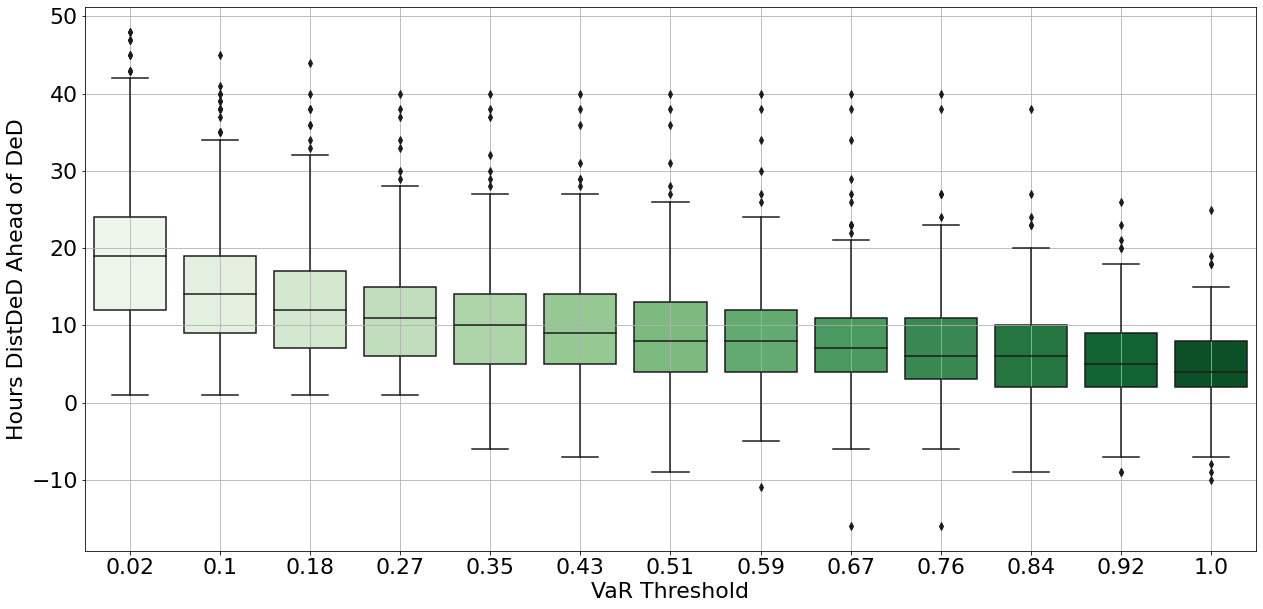

In [136]:
plt.figure(figsize=(30,10))
sns.boxplot(x='VaR Threshold', y='Hours Ahead', data=s_flags_cql_df, palette="Greens")
plt.grid()
plt.title("IQN+CQL: Surviving, Hours Ahead")
plt.show()

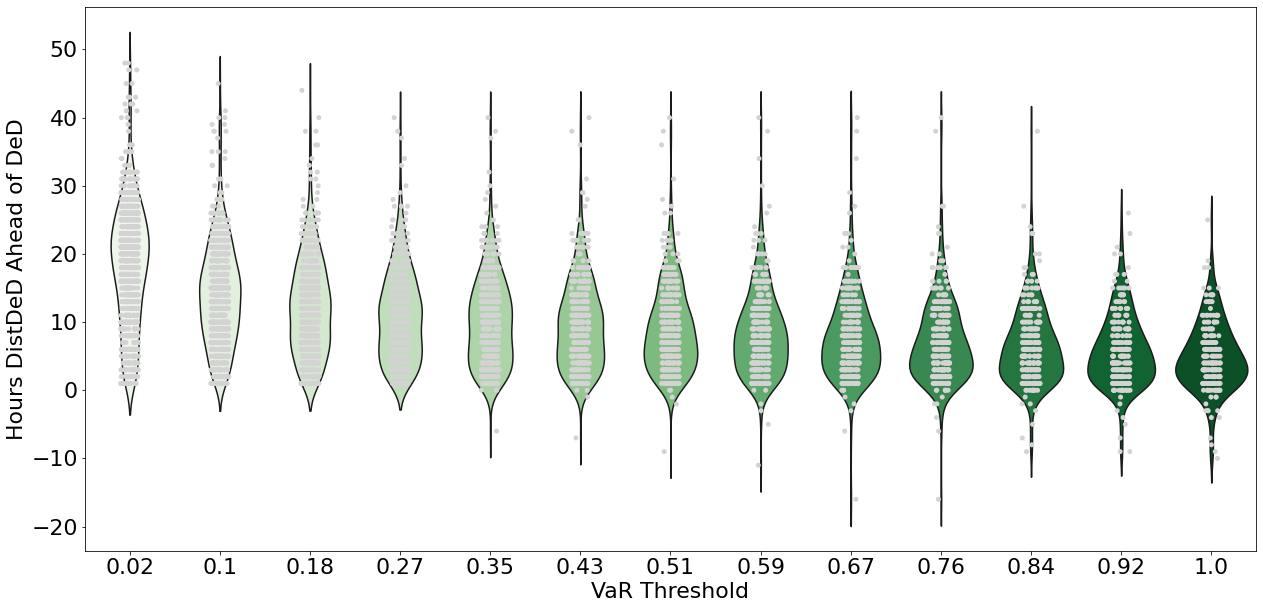

In [137]:
plt.figure(figsize=(21,10))
sns.violinplot(x="VaR Threshold", y="Hours Ahead", data=s_flags_cql_df, palette="Greens", inner=None)
sns.stripplot(x="VaR Threshold", y="Hours Ahead", data=s_flags_cql_df, color="lightgray", edgecolor="gray")
plt.title("IQN+CQL: Surviving, Hours Ahead")
plt.show()

Combining the DistDeD vs DeD histograms for both Non-survivors and Survivors...

In [146]:
flags_cql_df = pd.concat([ns_flags_cql_df, s_flags_cql_df]).reset_index(drop=True)

In [147]:
ns_cmap = sns.color_palette("Blues", n_colors=13)
s_cmap = sns.color_palette("Greens", n_colors=13)

'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'crest', 'crest_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'flare', 'flare_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'icefire', 'icefire_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'mako', 'mako_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'rocket', 'rocket_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'viridis', 'viridis_r', 'vlag', 'vlag_r', 'winter', 'winter_r'

In [150]:
test = VaR_thresholds  # all 20 VaR thresholds

array([0.02, 0.1 , 0.18, 0.27, 0.35, 0.43, 0.51, 0.59, 0.67, 0.76, 0.84,
       0.92, 1.  , 1.2 , 1.35])

In [148]:
custom_palette = ['#eb397b', '#387547']

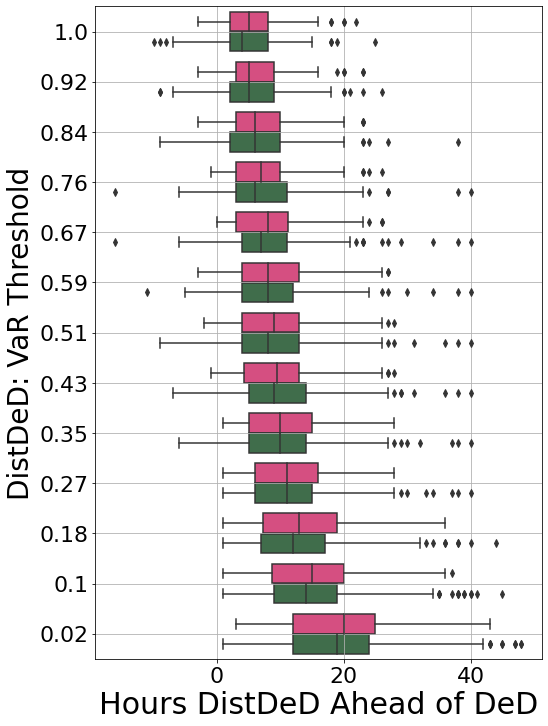

In [155]:
plt.figure(figsize=(12,16))
g = sns.boxplot(y='VaR Threshold', x='Hours Ahead', hue='type', data=flags_cql_df, palette=sns.color_palette(custom_palette, 2), orient='h', order=test[::-1])
plt.legend([],[], frameon=False)
plt.grid()
plt.xlabel("Hours Ahead", fontsize=30)
plt.ylabel("DistDeD: VaR Threshold", fontsize=28)
plt.title("IQN+CQL: Hours Ahead by Patient Type")
plt.show()

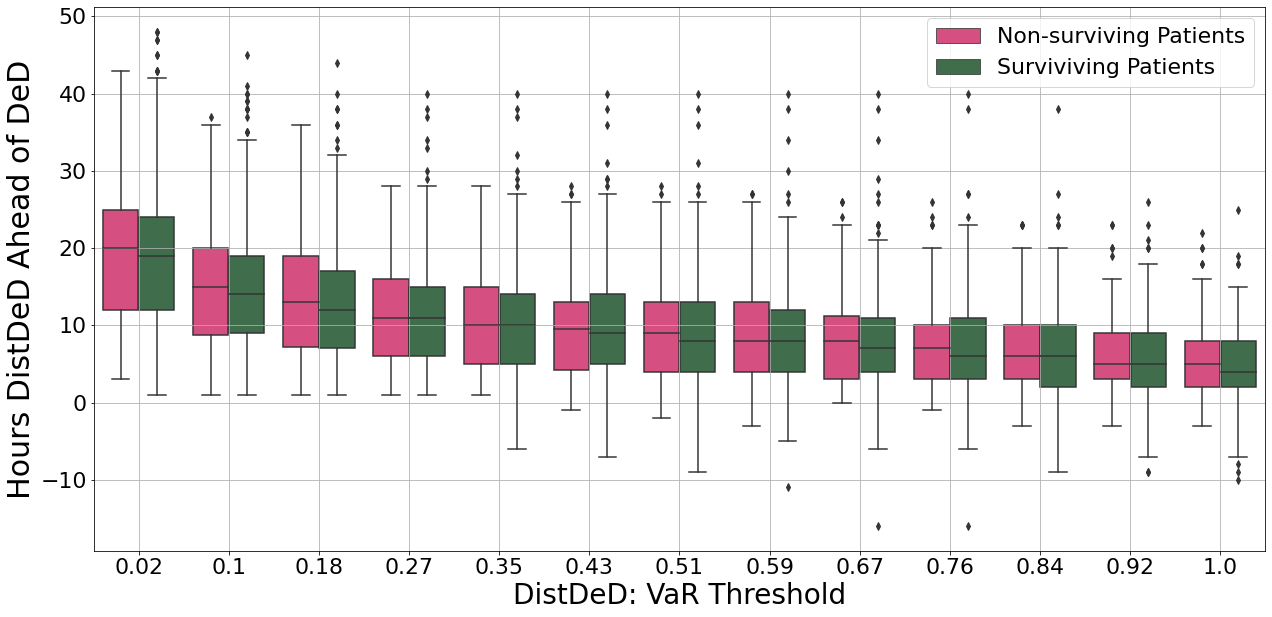

In [286]:
plt.figure(figsize=(30,10))
sns.boxplot(x='VaR Threshold', y='Hours Ahead', hue='type', data=flags_cql_df, palette=sns.color_palette(custom_palette, 2))
plt.grid()
plt.legend()
plt.ylabel("Hours Ahead", fontsize=30)
plt.xlabel("DistDeD: VaR Threshold", fontsize=28)
plt.title("IQN+CQL: Hours Ahead by Patient Type")
plt.show()

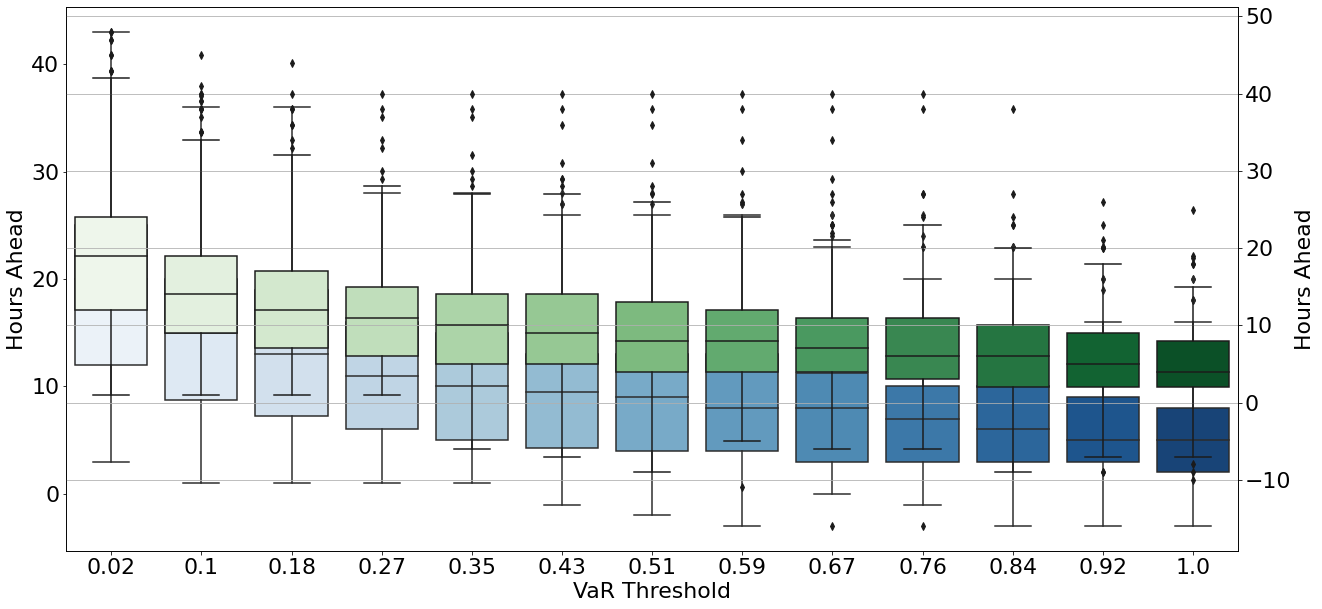

In [171]:
fig,ax= plt.subplots(figsize=(30,10))
tmpNS = flags_cql_df.copy()
tmpNS.loc[flags_cql_df['type']!='Non-surviving Patients','Hours Ahead'] = np.nan
tmpS = flags_cql_df.copy()
tmpS.loc[flags_cql_df['type']!='Surviviving Patients','Hours Ahead'] = np.nan
ax=sns.boxplot(ax=ax,x='VaR Threshold', y = 'Hours Ahead', data=tmpNS, palette='Blues')
ax2 = ax.twinx()
sns.boxplot(ax=ax2,x='VaR Threshold', y = 'Hours Ahead', data=tmpS, palette = 'Greens')
plt.grid()
plt.title("IQN+CQL: Non-surviving vs Surviving, Hours Ahead")
plt.show()
plt.close('all')

In [ ]:
# Continuous IQN hours-ahead plots
def first_flag_hours_by_threshold(v_dn, v_rn, steps, thresholds):
    v_dn = np.asarray(v_dn, dtype=np.float32)
    v_rn = np.asarray(v_rn, dtype=np.float32)
    if v_dn.ndim == 1:
        v_dn = v_dn[:, None]
        v_rn = v_rn[:, None]
    out = np.full(len(thresholds), np.nan, dtype=np.float32)
    for i, thr in enumerate(thresholds):
        col = i if v_dn.shape[1] > 1 else 0
        flagged = (v_dn[:, col] < (thr - 1.0)) & (v_rn[:, col] < thr)
        if np.any(flagged):
            first_idx = np.argmax(flagged)
            out[i] = -steps[first_idx]
    return out

def build_hours_ahead_df(surv_df, nonsurv_df, model_label, thresholds):
    ns_flags = []
    for traj in sorted(nonsurv_df.traj.unique()):
        dt = nonsurv_df[nonsurv_df.traj == traj]
        v_dn = _stack_traj_values(dt['v_dn'])
        v_rn = _stack_traj_values(dt['v_rn'])
        steps = dt['step'].to_numpy()
        ns_flags.append(first_flag_hours_by_threshold(v_dn, v_rn, steps, thresholds))
    ns_flags = np.vstack(ns_flags)
    temp_ns = np.repeat(thresholds[None, :], ns_flags.shape[0], axis=0)
    ns_comp = np.hstack([ns_flags.flatten('F')[:, None], temp_ns.flatten('F')[:, None]])
    ns_df = pd.DataFrame(ns_comp, columns=['Hours Ahead', 'VaR Threshold'])
    ns_df['type'] = 'Non-surviving Patients'
    ns_df['Model'] = model_label

    s_flags = []
    for traj in sorted(surv_df.traj.unique()):
        dt = surv_df[surv_df.traj == traj]
        v_dn = _stack_traj_values(dt['v_dn'])
        v_rn = _stack_traj_values(dt['v_rn'])
        steps = dt['step'].to_numpy()
        s_flags.append(first_flag_hours_by_threshold(v_dn, v_rn, steps, thresholds))
    s_flags = np.vstack(s_flags)
    temp_s = np.repeat(thresholds[None, :], s_flags.shape[0], axis=0)
    s_comp = np.hstack([s_flags.flatten('F')[:, None], temp_s.flatten('F')[:, None]])
    s_df = pd.DataFrame(s_comp, columns=['Hours Ahead', 'VaR Threshold'])
    s_df['type'] = 'Surviviving Patients'
    s_df['Model'] = model_label

    return pd.concat([ns_df, s_df], ignore_index=True)

VaR_thresholds_plot = np.round(np.linspace(0.05, 1.0, num=20), decimals=2)
iqn_hours_df = build_hours_ahead_df(iqn_cql_surv_df, iqn_cql_nonsurv_df, "IQN+CQL", VaR_thresholds_plot)
iqn_base_hours_df = build_hours_ahead_df(iqn_baseline_surv_df, iqn_baseline_nonsurv_df, "IQN Baseline", VaR_thresholds_plot)
cont_hours_df = build_hours_ahead_df(cont_surv_df, cont_nonsurv_df, "Continuous IQN", VaR_thresholds_plot)

hours_df = pd.concat([iqn_hours_df, iqn_base_hours_df, cont_hours_df], ignore_index=True)

plt.figure(figsize=(14, 16))
ns_hours = hours_df[hours_df['type'] == 'Non-surviving Patients']
sns.boxplot(y='VaR Threshold', x='Hours Ahead', hue='Model', data=ns_hours,
            orient='h', order=VaR_thresholds_plot[::-1])
plt.grid()
plt.xlabel("Hours Ahead")
plt.ylabel("VaR Threshold")
plt.title("Hours Ahead by Model (Non-surviving Patients)")
plt.legend(fontsize=12)
plt.show()

plt.figure(figsize=(14, 16))
s_hours = hours_df[hours_df['type'] == 'Surviviving Patients']
sns.boxplot(y='VaR Threshold', x='Hours Ahead', hue='Model', data=s_hours,
            orient='h', order=VaR_thresholds_plot[::-1])
plt.grid()
plt.xlabel("Hours Ahead")
plt.ylabel("VaR Threshold")
plt.title("Hours Ahead by Model (Surviviving Patients)")
plt.legend(fontsize=12)
plt.show()